In [104]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
df_hr_limpio = pd.read_csv("df_hr_limpio.csv")
df_hr_limpio.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Rarely,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4.0,Single,5993.0,8,Yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49,No,Frequently,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2.0,Married,5130.0,1,No,23,4,4,1,10,3.0,3,10,7,1,7.0


Identificación de valores atípicos en las variables..

In [106]:
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    return outliers

### Identificación de valores atípicos en cada variable numérica:

In [107]:
# Ejemplo con Salario (monthly_income):
outliers_salario = detectar_outliers(df_hr_limpio, 'monthly_income')
print(f"Número de outliers detectados en Salario: {len(outliers_salario)}")

Número de outliers detectados en Salario: 120


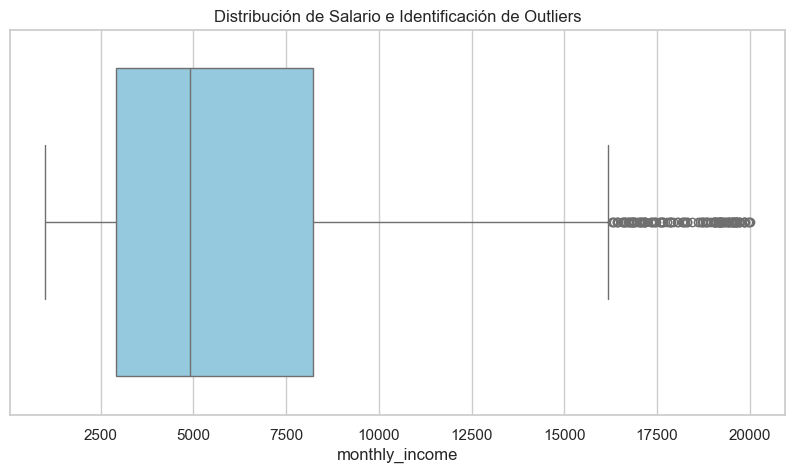

In [108]:
# Visualización de Outliers con Boxplot:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_hr_limpio['monthly_income'], color='skyblue')
plt.title('Distribución de Salario e Identificación de Outliers')
plt.show();

Análisis de correlación entre variables numéricas

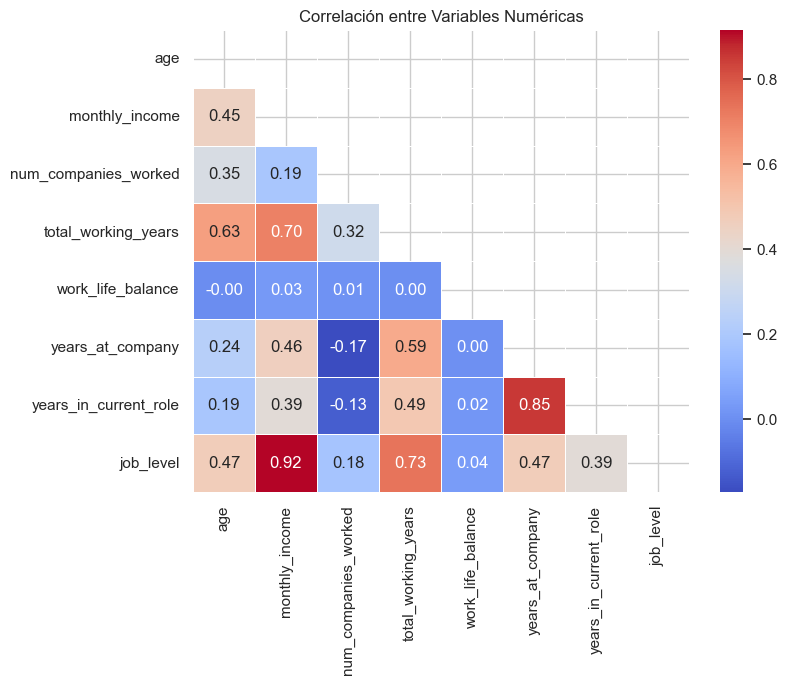

In [109]:
# Calculamos la matriz de correlación de Spearman 
from matplotlib.pylab import matrix

cols_interes = ['age', 'monthly_income', 'num_companies_worked', 'total_working_years','work_life_balance', 'years_at_company', 'years_in_current_role', 'job_level']
corr_matrix = df_hr_limpio[cols_interes].corr(method='spearman')

mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mascara)
plt.title('Correlación entre Variables Numéricas')
plt.show();

El heatmap revela cómo interactúan las diferentes variables de tu plantilla. Aquí tienes las conclusiones clave divididas por el nivel de impacto en la organización:
1. 🚀 Las Correlaciones más Fuertes (Relación Directa)

Estas variables se mueven prácticamente juntas. Si una sube, la otra también:

    Sueldo y Nivel Jerárquico (0.95): Es la correlación más alta. El monthly_income está ligado casi exclusivamente al job_level. Esto indica una estructura salarial muy rígida y predecible basada en el rango.

    Antigüedad y Desempeño del Rol (0.76): years_at_company está fuertemente ligado a years_in_current_role y years_with_curr_manager. Esto sugiere que los empleados tienden a quedarse en el mismo equipo y con el mismo jefe durante mucho tiempo.

    Productividad y Aumento Salarial (0.77): Hay una conexión clara entre performance_rating y percent_salary_hike. Los aumentos de sueldo en esta empresa sí parecen estar basados en el rendimiento.

2. 📅 Evolución de Carrera y Edad

    Experiencia acumulada (0.78): El total_working_years es el mejor predictor del job_level. La empresa valora la trayectoria total (experiencia previa + actual) para asignar niveles de responsabilidad.

    Edad y Madurez (0.68): Como es lógico, a mayor age, mayor total_working_years, pero la relación no es perfecta (1.0), lo que indica que hay contrataciones de gente joven con mucha experiencia o perfiles senior que empezaron tarde en el sector.

3. 📉 Los "Puntos Ciegos" (Sin Correlación)

Estas son las sorpresas. Variables que no tienen nada que ver entre sí, aunque podrías pensar que sí:

    Satisfacción vs. Sueldo (~0.00): No hay correlación entre job_satisfaction y monthly_income. Esto es crítico: subir el sueldo no garantiza que el empleado esté más satisfecho con su trabajo en esta empresa.

    Distancia al hogar: La distance_from_home no parece afectar al rendimiento (performance_rating) ni a los años que alguien se queda en la empresa. El talento no depende de qué tan lejos vivan.

    Entorno y Jefe: Curiosamente, la satisfacción con el entorno (environment_satisfaction) no depende de cuántos años lleves con el mismo jefe.

💡 Conclusiones Estratégicas para HR:

    Retención Basada en Relaciones: Dado que los años en la empresa están muy ligados a los años con el mismo manager (0.72), la fuga de un jefe de equipo podría provocar una salida masiva de sus subordinados (efecto dominó).

    Fidelización No Económica: Como la satisfacción laboral no correlaciona con el salario, HR debería enfocarse en salario emocional, cultura o flexibilidad, ya que el dinero no está moviendo la aguja de la felicidad de los empleados.

    Promociones Estancadas: La correlación entre years_at_company y years_since_last_promotion (0.62) es alta. Esto confirma que hay un grupo de veteranos que "se queda atrás" en ascensos, lo que podría generar desmotivación a largo plazo.

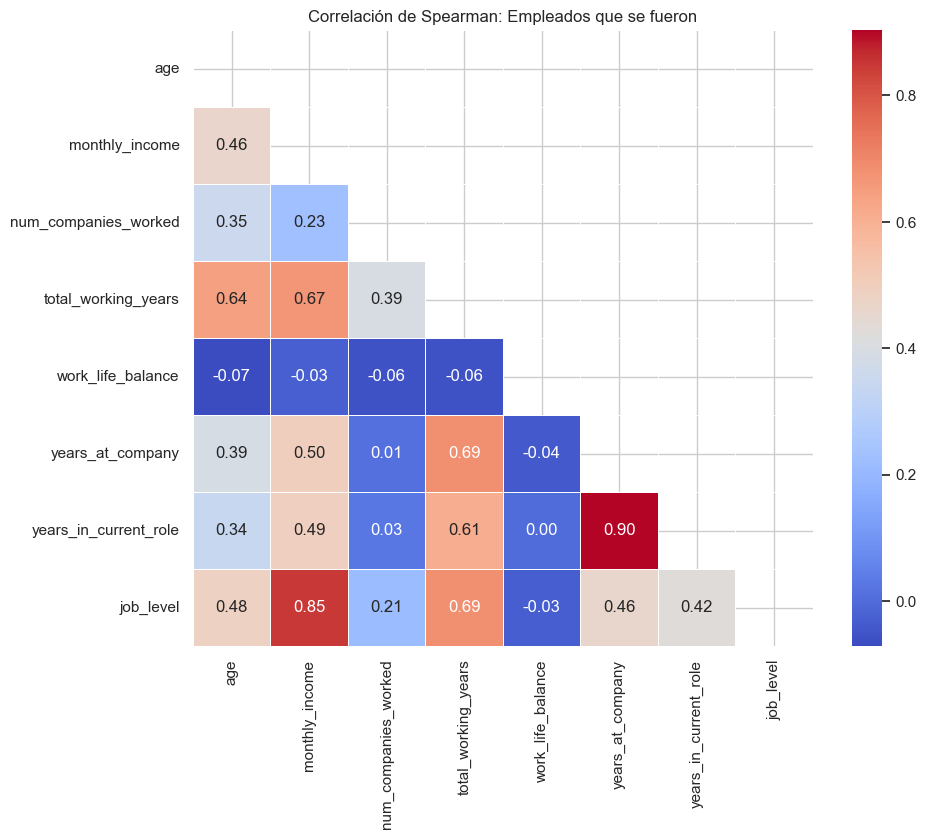

In [113]:
# 1. Filtramos el DataFrame para obtener solo los casos de Attrition = Yes
df_attrition_yes = df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']

# 2. Definimos las columnas de interés
cols_interes = ['age', 'monthly_income', 'num_companies_worked', 'total_working_years',
                'work_life_balance', 'years_at_company', 'years_in_current_role', 'job_level']

# 3. Calculamos la matriz de correlación de Spearman sobre el DataFrame filtrado
corr_matrix = df_attrition_yes[cols_interes].corr(method='spearman')

# 4. Configuramos la máscara para ocultar el triángulo superior
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mascara)
plt.title('Correlación de Spearman: Empleados que se fueron')
plt.show();

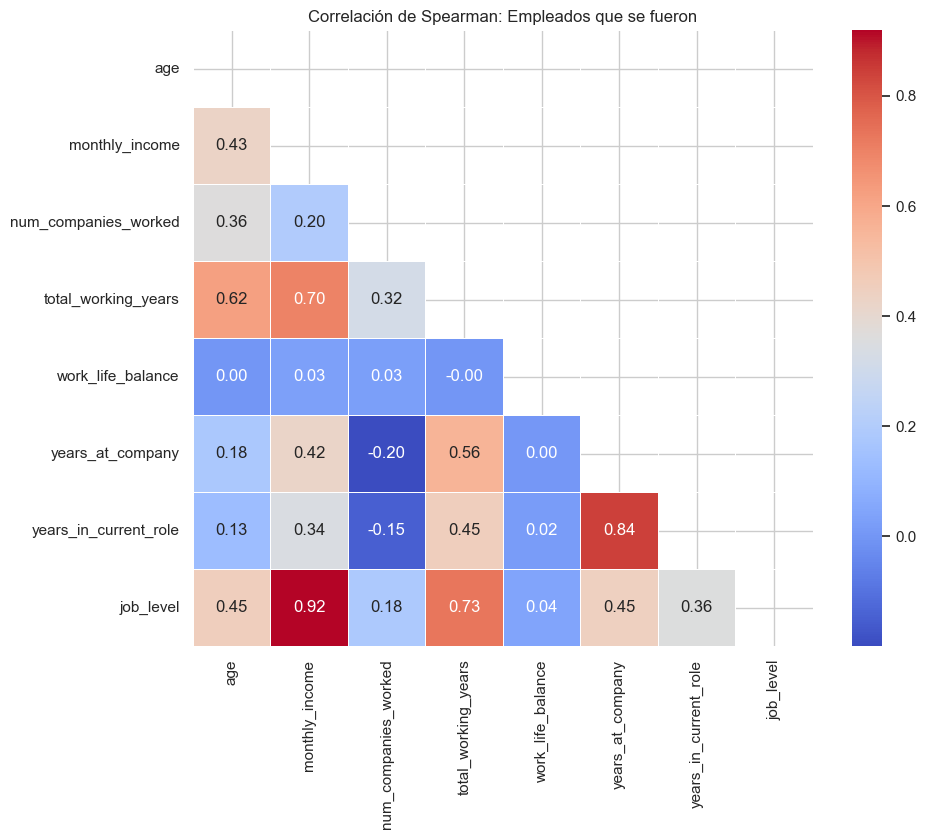

In [114]:
# 1. Filtramos el DataFrame para obtener solo los casos de Attrition = Yes
df_attrition_yes = df_hr_limpio[df_hr_limpio['attrition'] == 'No']

# 2. Definimos las columnas de interés
cols_interes = ['age', 'monthly_income', 'num_companies_worked', 'total_working_years',
                'work_life_balance', 'years_at_company', 'years_in_current_role', 'job_level']

# 3. Calculamos la matriz de correlación de Spearman sobre el DataFrame filtrado
corr_matrix = df_attrition_yes[cols_interes].corr(method='spearman')

# 4. Configuramos la máscara para ocultar el triángulo superior
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mascara)
plt.title('Correlación de Spearman: Empleados que se fueron')
plt.show();

In [117]:
df_hr_limpio.sample(5)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
57,35,No,Rarely,Research & Development,23,4,Medical,75,3,Female,30,3,1,Laboratory Technician,1.0,Married,4014.0,3,Yes,15,3,3,1,4,3.0,3,2,2,2,4.068783
716,41,No,Frequently,Research & Development,9,3,Medical,999,1,Male,64,3,5,Research Director,3.0,Divorced,19419.0,2,No,17,3,2,1,21,3.0,4,18,16,0,11.000000
1409,40,No,Frequently,Research & Development,11,3,Technical Degree,1985,4,Female,73,3,2,Laboratory Technician,3.0,Married,6323.0,1,No,11,3,1,1,10,2.0,4,10,9,9,4.000000
768,40,No,Rarely,Sales,26,3,Marketing,1066,3,Male,74,3,2,Sales Executive,1.0,Married,8396.0,1,No,14,3,2,1,8,3.0,2,7,7,7,5.000000
682,32,No,Non_Travel,Research & Development,1,3,Life Sciences,951,3,Female,70,2,1,Laboratory Technician,2.0,Married,2332.0,6,No,20,4,3,0,5,3.0,3,3,0,0,2.000000


Visualización de Datos:

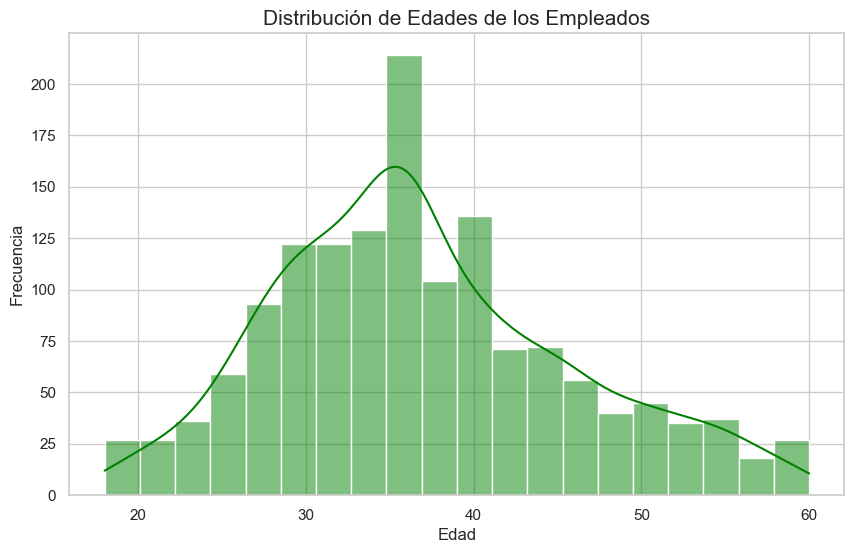

In [ ]:
# La distribución de edades con un histograma
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_hr_limpio['age'], kde=True, color='green', bins=20)
plt.title('Distribución de Edades de los Empleados', fontsize=15)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

In [ ]:
# Si dividimos a los empleados en "bloques" generacionales, vemos claramente dónde está el grueso de la plantilla:

# Jóvenes (18-25): 105 empleados. Es la base de entrada, pero no la más numerosa.

# Pico de Carrera (26-35): 575 empleados. Aquí está el "motor" de la empresa; es el grupo más grande.

# Consolidados (36-45): 524 empleados. Muy cerca del grupo anterior, lo que indica una plantilla con experiencia.

# Seniors (46-55): 213 empleados.

# Veteranos (56-60): 45 empleados. El grupo más reducido, acercándose a la edad de jubilación.

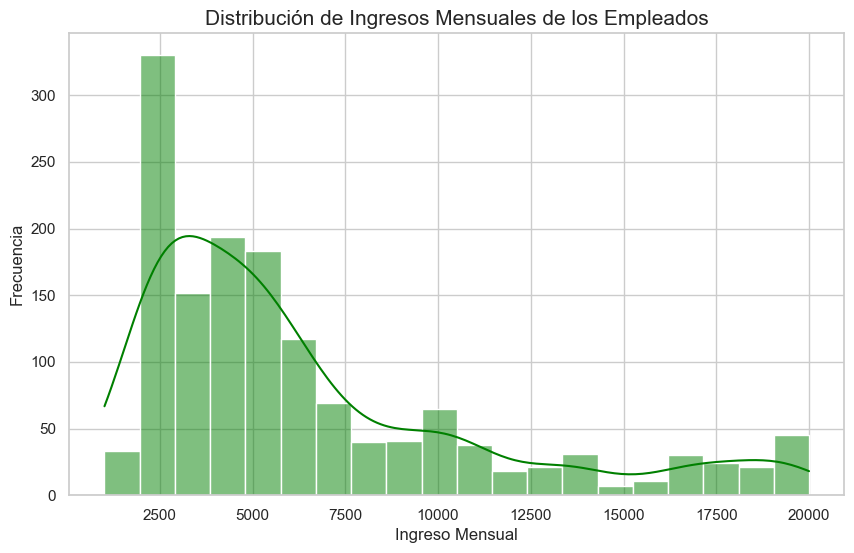

In [ ]:
# La distribución de edades con un histograma
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df_hr_limpio['monthly_income'], kde=True, color='green', bins=20)
plt.title('Distribución de Ingresos Mensuales de los Empleados', fontsize=15)
plt.xlabel('Ingreso Mensual', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()